# Лабораторная работа № 4

# Бинарная классификация

**Цель работы:** познакомиться с применением модели машинного обучения для решения задачи классификации (метод логистической регрессии).

Проанализируем датасет cancer_data. Датасет содержит медицинскую статистику и данные об образе жизни 1500 пациентов. Также он содержит информацию о наличии или отсутствии онкологического заболевания. Смысл задачи — определять, основываясь на этих данных, есть ли у пациента рак или нет. Набор данных включает следующие атрибуты:
- **Age** – возраст пациента (от 20 до 80 лет);
- **Gender** – пол (0 – мужской, 1 – женский);
- **BMI** – индекс массы тела (от 15 до 40);
- **Smoking** – статус курения (0 – нет, 1 – да);
- **GeneticRisk** – уровень генетического риска (0 – низкий, 1 – средний, 2 – высокий);
- **PhysicalActivity** – часы физической активности в неделю (от 0 до 10);
- **AlcoholIntake** – потребление алкоголя в неделю (от 0 до 5);
- **CancerHistory** – наличие онкологии в анамнезе (0 – нет, 1 – да);
- **Diagnosis** – целевая переменная (0 – рак не обнаружен, 1 – рак обнаружен).

# 0. Импортируем библиотеки и загружаем данные

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("cancer_data.csv")
df.head()

,Age,Gender,BMI,Smoking,GeneticRisk,PhysicalActivity,AlcoholIntake,CancerHistory,Diagnosis
0,58,1,16.085313,0,1,8.146251,4.148219,1,1
1,71,0,30.828784,0,1,9.361630,3.519683,0,0
2,48,1,38.785084,0,2,5.135179,4.728368,0,1
3,34,0,30.040296,0,0,9.502792,2.044636,0,0
4,62,1,35.479721,0,0,5.356890,3.309849,0,1


# 1. Извлечём последнюю строку датафрейма (практическое применение)

In [3]:
row_to_remove = df.iloc[1499]
df = df.drop(1499)

In [4]:
print("\nУдалённая строка (Series):")
print(row_to_remove)
print(f"Тип: {type(row_to_remove)}")


Удалённая строка (Series):
Age                 67.000000
Gender               1.000000
BMI                 23.663104
Smoking              0.000000
GeneticRisk          0.000000
PhysicalActivity     2.525860
AlcoholIntake        2.856600
CancerHistory        1.000000
Diagnosis            0.000000
Name: 1499, dtype: float64
Тип: <class 'pandas.core.series.Series'>


# 2. Проанализируем значения целевой переменной

Выведем целевую переменную, уникальные значения и частоту каждого уникального значения:

In [5]:
(unique, counts) = np.unique(df['Diagnosis'], return_counts=True)
print('Unique values of the target variable: ', unique)
print('Counts of the target variable:', counts)

Unique values of the target variable:  [0 1]
Counts of the target variable: [942 557]


Построим столбчатую диаграмму, чтобы увидеть целевую переменную:

<Axes: xlabel='Diagnosis', ylabel='count'>

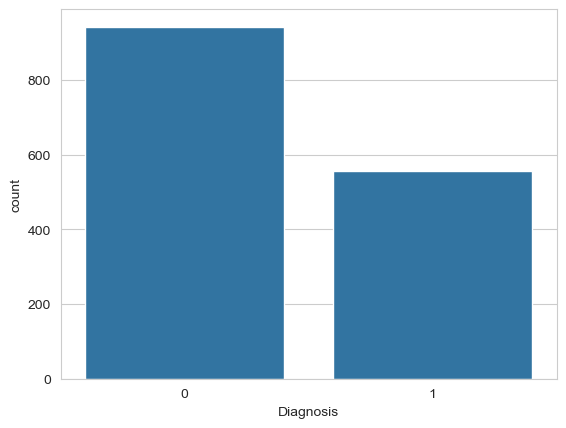

In [6]:
sns.set_style("whitegrid")
sns.countplot(df, x = 'Diagnosis')

> Диаграмма показывает, что набор данных является сбалансированным. В датасете два класса: 0 (рак не обнаружен) — 942 наблюдения и 1 (рак обнаружен) — 557 наблюдений.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1499 entries, 0 to 1498
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1499 non-null   int64  
 1   Gender            1499 non-null   int64  
 2   BMI               1499 non-null   float64
 3   Smoking           1499 non-null   int64  
 4   GeneticRisk       1499 non-null   int64  
 5   PhysicalActivity  1499 non-null   float64
 6   AlcoholIntake     1499 non-null   float64
 7   CancerHistory     1499 non-null   int64  
 8   Diagnosis         1499 non-null   int64  
dtypes: float64(3), int64(6)
memory usage: 105.5 KB


> В нашем наборе данных два класса: 0 и 1, что делает эту задачу задачей бинарной классификации.

# 3. Проверяем наличие пропущенных значений и выбросов

In [8]:
print(df.isnull().sum())

Age                 0
Gender              0
BMI                 0
Smoking             0
GeneticRisk         0
PhysicalActivity    0
AlcoholIntake       0
CancerHistory       0
Diagnosis           0
dtype: int64


> Пропущенные значения в датасете отсутствуют, обработка пропусков не требуется.

Проверим на наличие выбросов:

<Axes: xlabel='Age'>

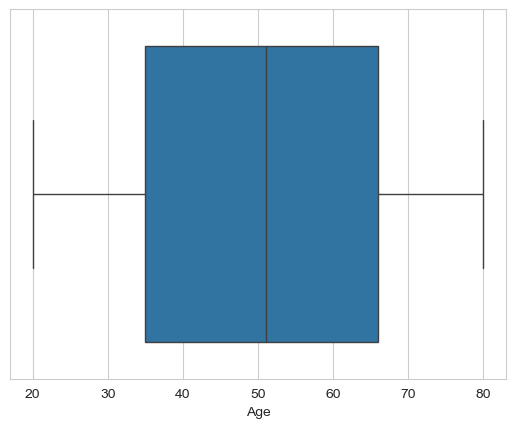

In [9]:
sns.boxplot(x=df['Age'])

> На диаграмме видно, что выбросы в признаке Age отсутствуют — все значения находятся в пределах допустимого диапазона от 20 до 80 лет.

# 4. Исключаем невлияющие категориальные признаки

В данном датасете все признаки являются числовыми и значимыми для прогнозирования, невлияющие категориальные признаки отсутствуют. Исключение столбцов не требуется.

# 5. Заполняем пропущенные значения

Как было показано ранее, пропущенные значения в датасете отсутствуют. Заполнение пропусков не требуется.

# 6. Кодируем категориальные признаки

Все признаки в датасете уже представлены в числовом формате, кодирование не требуется.

# 7. Разделяем данные на признаки и целевую переменную

In [10]:
y = df['Diagnosis']
X = df.drop('Diagnosis', axis=1)

In [11]:
X

,Age,Gender,BMI,Smoking,GeneticRisk,PhysicalActivity,AlcoholIntake,CancerHistory
0,58,1,16.085313,0,1,8.146251,4.148219,1
1,71,0,30.828784,0,1,9.361630,3.519683,0
2,48,1,38.785084,0,2,5.135179,4.728368,0
3,34,0,30.040296,0,0,9.502792,2.044636,0
4,62,1,35.479721,0,0,5.356890,3.309849,0
...,...,...,...,...,...,...,...,...
1494,79,1,17.832588,0,0,5.909161,4.880353,0
1495,62,1,25.090025,0,0,9.892167,1.284158,0
1496,31,0,33.447125,0,1,1.668297,2.280636,1
1497,63,1,32.613861,1,1,0.466848,0.150101,0


# 8. Разделяем данные на тренировочный и тестовый наборы

75% данных используется для обучения и 25% — для тестирования.

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

# 9. Применяем операцию нормализации для численной устойчивости

In [13]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 10. Обучаем модель логистической регрессии

In [14]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


# 11. Делаем прогноз на основе данных тестирования

In [15]:
y_pred = model.predict(X_test_scaled)

# 12. Рассчитываем показатели точности, сравнив фактические и прогнозируемые значения

In [16]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = confusion_matrix(y_test, y_pred).ravel()

print('True Positive(TP)  = ', TP)
print('False Positive(FP) = ', FP)
print('True Negative(TN)  = ', TN)
print('False Negative(FN) = ', FN)

accuracy =  (TP+TN) /(TP+FP+TN+FN)
print('Accuracy of the binary classification = {:0.3f}'.format(accuracy))

True Positive(TP)  =  109
False Positive(FP) =  16
True Negative(TN)  =  216
False Negative(FN) =  34
Accuracy of the binary classification = 0.867


> Модель правильно определила 109 случаев наличия рака (TP) и 216 случаев отсутствия рака (TN). При этом 16 раз модель ошибочно предсказала рак (FP) и 34 раза пропустила реальный рак (FN). Общая точность бинарной классификации составила 0.867 (86.7%).

Оцениваем точность, полноту и F1-меру модели:

In [17]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f"Точность: {accuracy:.2f}")

Точность: 0.87


In [18]:
from sklearn.metrics import precision_score, recall_score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
print(f"Точность: {precision:.2f}")
print(f"Полнота: {recall:.2f}")

Точность: 0.87
Полнота: 0.76


In [19]:
from sklearn.metrics import f1_score
f1 = f1_score(y_test, y_pred)
print(f"F1-мера: {f1:.2f}")

F1-мера: 0.81


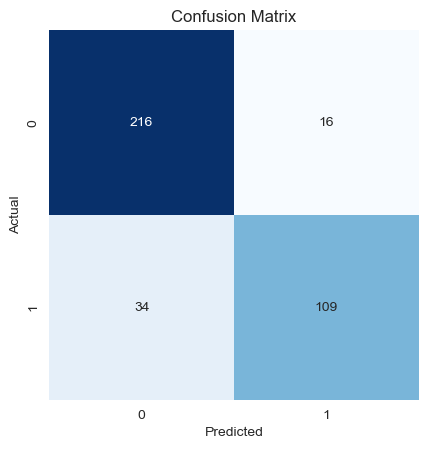

In [20]:
sns.heatmap(cm, square=True, annot=True, fmt='d', cbar=False, cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

> Точность (accuracy) модели составила 0.87, то есть 87% предсказаний оказались верными — это хороший результат. Precision = 0.87 — из всех пациентов, которым модель предсказала рак, 87% действительно больны. Полнота (recall) = 0.76 — модель обнаружила 76% реально больных пациентов, что означает, что часть случаев заболевания всё же была пропущена. F1-мера = 0.81 — среднее гармоническое между точностью и полнотой. В целом модель показывает достаточно высокую точность и может использоваться для прогнозирования наличия рака.

# 13. Корреляционная матрица

In [21]:
df.corr()

,Age,Gender,BMI,Smoking,GeneticRisk,PhysicalActivity,AlcoholIntake,CancerHistory,Diagnosis
Age,1.000000,0.006506,0.030594,-0.013537,-0.026565,0.016927,0.003015,-0.012563,0.197186
Gender,0.006506,1.000000,-0.012159,0.035814,-0.004167,0.023978,0.009517,0.006014,0.250995
BMI,0.030594,-0.012159,1.000000,-0.012834,0.011129,0.011189,0.004822,-0.009978,0.187341
Smoking,-0.013537,0.035814,-0.012834,1.000000,-0.021349,-0.044168,-0.001535,0.017392,0.226760
GeneticRisk,-0.026565,-0.004167,0.011129,-0.021349,1.000000,-0.040152,-0.016713,-0.009635,0.253185
PhysicalActivity,0.016927,0.023978,0.011189,-0.044168,-0.040152,1.000000,0.034036,0.019526,-0.150577
AlcoholIntake,0.003015,0.009517,0.004822,-0.001535,-0.016713,0.034036,1.000000,0.055011,0.212979
CancerHistory,-0.012563,0.006014,-0.009978,0.017392,-0.009635,0.019526,0.055011,1.000000,0.394298
Diagnosis,0.197186,0.250995,0.187341,0.226760,0.253185,-0.150577,0.212979,0.394298,1.000000


> Наибольшую положительную корреляцию с целевой переменной Diagnosis показывают признаки CancerHistory (0.39), GeneticRisk (0.25), Gender (0.25) и Smoking (0.23). Это означает, что наличие онкологии в анамнезе, высокий генетический риск, женский пол и курение повышают вероятность обнаружения рака. Отрицательная корреляция наблюдается у PhysicalActivity (-0.15) — чем больше физической активности, тем ниже вероятность заболевания. Остальные признаки (Age, BMI, AlcoholIntake) имеют слабую корреляцию с Diagnosis. Между самими признаками сильных взаимосвязей не выявлено.

# 14. Строим ROC-кривую

In [22]:
from sklearn.metrics import roc_curve, auc
y_score = model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

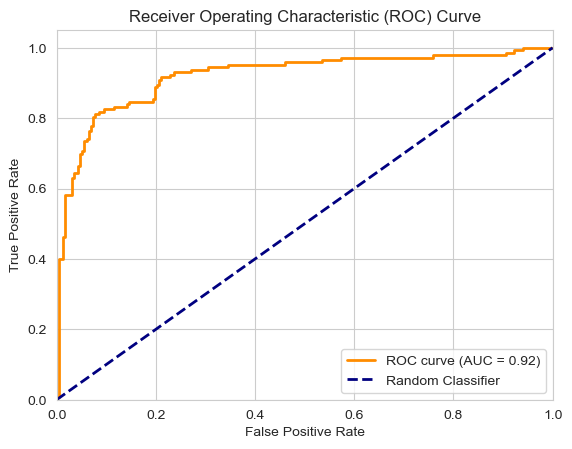

In [23]:
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

> ROC-кривая значительно выше диагональной линии случайного классификатора, что подтверждает хорошее качество модели. Площадь под кривой AUC = 0.92 — это высокий показатель, означающий, что модель отлично различает пациентов с раком и без рака. Модель логистической регрессии хорошо справляется с задачей прогнозирования на данном датасете.

# 15. Подготовка новых данных для прогноза

In [24]:
new_data = pd.DataFrame({
    'Age': [67],
    'Gender': [1],
    'BMI': [23.663104],
    'Smoking': [0],
    'GeneticRisk': [0],
    'PhysicalActivity': [2.525860],
    'AlcoholIntake': [2.856600],
    'CancerHistory': [1]
})

In [25]:
new_data_scaled = scaler.transform(new_data)

# 16. Делаем прогноз

In [26]:
predicted_class = model.predict(new_data_scaled)
print(f"Предсказанный класс: {predicted_class[0]}")

Предсказанный класс: 1


In [27]:
predicted_proba = model.predict_proba(new_data_scaled)
print(f"Вероятности для классов [0, 1]: {predicted_proba[0]}")

Вероятности для классов [0, 1]: [0.02634407 0.97365593]


In [28]:
probability_of_positive_class = predicted_proba[0][1]
print(f"Вероятность положительного исхода: {probability_of_positive_class:.2f}")

Вероятность положительного исхода: 0.97


> Модель предсказала класс 1 — наличие рака у данного пациента (это данные из ранее удалённой строки 1499). Вероятность наличия рака по мнению модели составила 0.97 (97%). Однако в исходном датасете у этого пациента Diagnosis = 0 (рак не обнаружен). Модель ошиблась, так как у пациента присутствуют выраженные факторы риска (онкология в анамнезе, возраст 67 лет, низкая физическая активность), которые статистически связаны с наличием рака. Это показывает, что модель не идеальна и может допускать ошибки в пограничных случаях.

# 17. Исследовательский анализ данных (EDA)

Настройка визуализации:

In [29]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

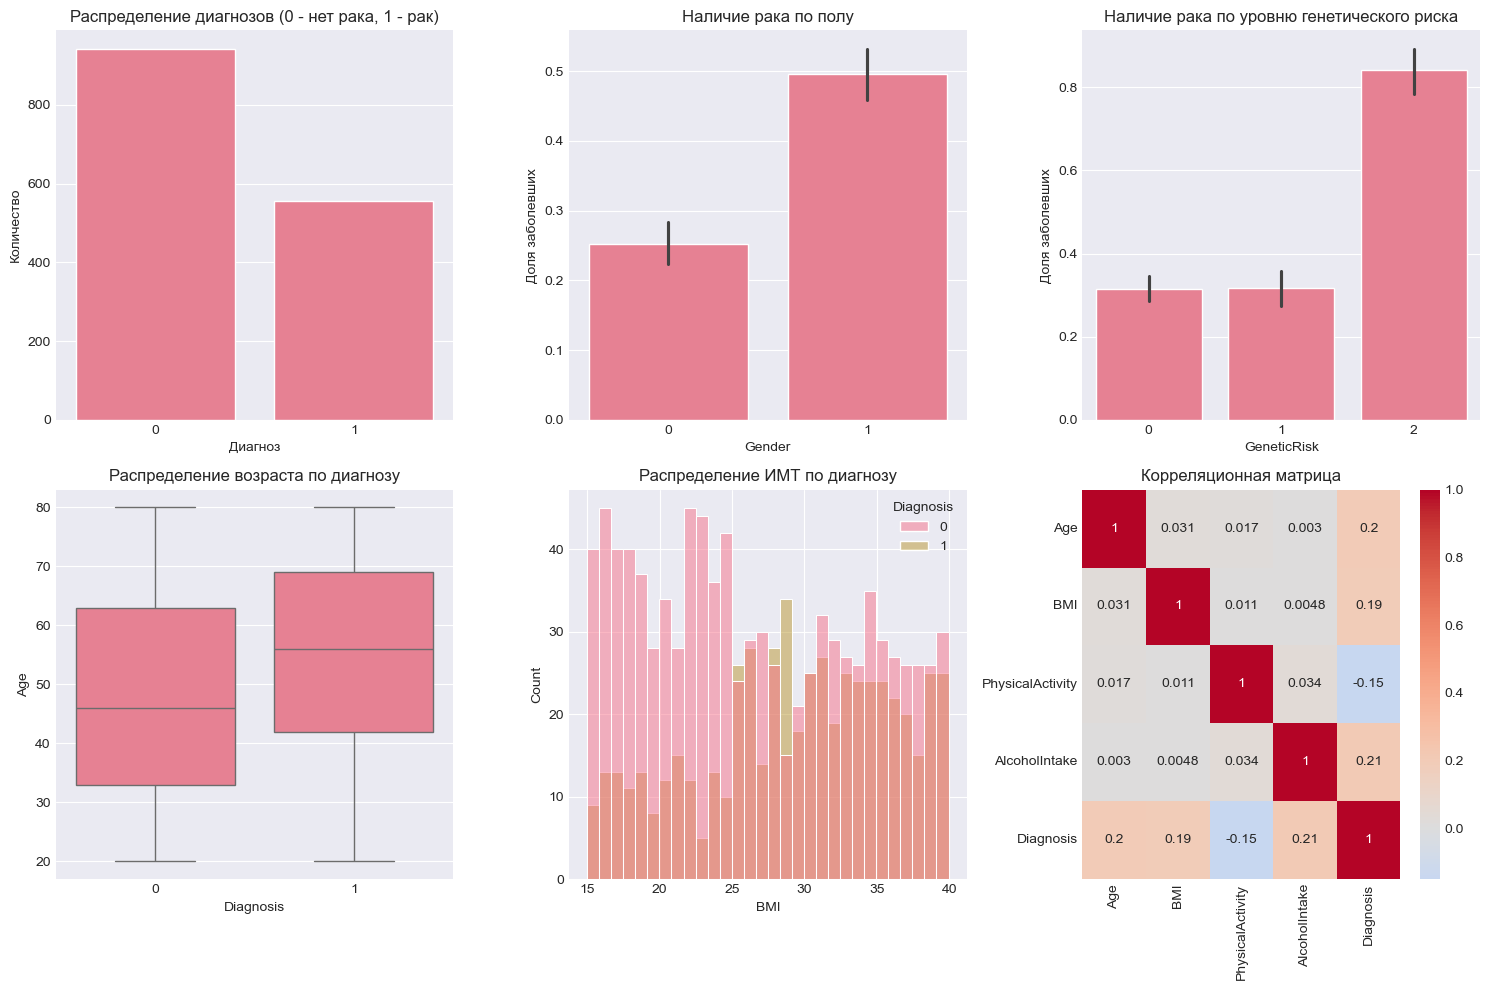

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

sns.countplot(data=df, x='Diagnosis', ax=axes[0, 0])
axes[0, 0].set_title('Распределение диагнозов (0 - нет рака, 1 - рак)')
axes[0, 0].set_xlabel('Диагноз')
axes[0, 0].set_ylabel('Количество')

sns.barplot(data=df, x='Gender', y='Diagnosis', ax=axes[0, 1])
axes[0, 1].set_title('Наличие рака по полу')
axes[0, 1].set_ylabel('Доля заболевших')

sns.barplot(data=df, x='GeneticRisk', y='Diagnosis', ax=axes[0, 2])
axes[0, 2].set_title('Наличие рака по уровню генетического риска')
axes[0, 2].set_ylabel('Доля заболевших')

sns.boxplot(data=df, x='Diagnosis', y='Age', ax=axes[1, 0])
axes[1, 0].set_title('Распределение возраста по диагнозу')

sns.histplot(data=df, x='BMI', hue='Diagnosis', bins=30, ax=axes[1, 1])
axes[1, 1].set_title('Распределение ИМТ по диагнозу')

numeric_cols = ['Age', 'BMI', 'PhysicalActivity', 'AlcoholIntake', 'Diagnosis']
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, ax=axes[1, 2])
axes[1, 2].set_title('Корреляционная матрица')

plt.tight_layout()
plt.show()

> Анализ графиков показывает следующее: набор данных содержит больше пациентов без рака (класс 0), чем с раком (класс 1). Женщины (Gender=1) болеют раком почти вдвое чаще мужчин (Gender=0). Высокий генетический риск (GeneticRisk=2) резко увеличивает долю заболевших — до 84%. Распределение возраста по диагнозу показывает, что пациенты с раком в среднем немного старше. Распределение ИМТ по диагнозу существенных различий не выявило. Корреляционная матрица подтверждает, что наибольшую связь с диагнозом имеют AlcoholIntake (0.21), Age (0.20) и BMI (0.19), а PhysicalActivity имеет отрицательную корреляцию (-0.15).